# EDA and Data Cleaning

Analyzing Coral Reef Degredation and Bleaching

CSCI 4022 Final Project

Gaeryth Ebert

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("global_bleaching_environmental.csv")
print("Shape:", df.shape)
df.head()

Shape: (41361, 62)


C:\Users\gaery\AppData\Local\Temp\ipykernel_26980\2195346974.py:1: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("global_bleaching_environmental.csv")


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,State_Island_Province_Name,City_Town_Name,Site_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Date_Day,Date_Month,Date_Year,Depth_m,Substrate_Name,Percent_Cover,Bleaching_Level,Percent_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Mean,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMax,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,SSTA_DHWMean,TSA,TSA_Standard_Deviation,TSA_Minimum,TSA_Maximum,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,Havana,Havana,Puntilla,8519.23,Exposed,0.0287,49.90,15,9,2005,10,nd,nd,nd,50.2,301.61,302.05,300.67,296.72,304.69,1.6,8,-0.46,1,0,-3.56,2.24,0,3.13,17,3,0,1.63,7.88,0.98,-0.8,1.6,-6.12,1.83,-2.17,0,1.09,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,Society Islands,Moorea,nd,1431.62,Exposed,0.0262,51.20,15,3,1991,14,nd,nd,nd,50.7,262.15,303.30,300.73,297.58,305.01,1.12,2,1.29,1,0,-2.73,3.1,0.5,2.77,13.25,2,0.26,1.48,11.41,0.72,1.29,1.12,-4.42,3.00,-1.26,0.25,0.93,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,British Virgin Islands,Peter Island,Coral Gardens,182.33,Exposed,0.0429,61.52,15,1,2006,7,nd,nd,nd,50.9,298.79,299.18,300.32,297.12,304.14,1.22,8,0.04,1,0,-2.92,2.83,16,4.52,23,3,0,2.45,16.24,1.26,-2.64,1.22,-4.69,2.31,-1.49,7,1.31,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3219,313.13,Exposed,0.0424,65.39,15,4,2006,9.02,nd,nd,nd,50.9,300.16,299.61,300.38,297.25,304.07,1.19,3,-0.07,1,0,-2.77,2.47,22,4.75,24,3,0,2.37,16.73,1.07,-2.27,1.19,-4.63,2.19,-1.49,3,0.94,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,US Virgin Islands,St. Croix,3194,792.0,Exposed,0.0424,65.39,15,4,2006,12.50,nd,nd,nd,50.9,300.15,299.7,300.38,296.63,303.76,1.18,3,0,1,0,-2.84,2.3,16,4.16,20,3,0,2.24,13.86,1.16,-2.19,1.18,-5.25,1.87,-1.5,3,1.33,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


In [3]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Site_ID', 'Sample_ID', 'Data_Source', 'Latitude_Degrees', 'Longitude_Degrees', 'Ocean_Name', 'Reef_ID', 'Realm_Name', 'Ecoregion_Name', 'Country_Name', 'State_Island_Province_Name', 'City_Town_Name', 'Site_Name', 'Distance_to_Shore', 'Exposure', 'Turbidity', 'Cyclone_Frequency', 'Date_Day', 'Date_Month', 'Date_Year', 'Depth_m', 'Substrate_Name', 'Percent_Cover', 'Bleaching_Level', 'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA', 'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW',

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Site_ID                                41361 non-null  int64  
 1   Sample_ID                              41361 non-null  int64  
 2   Data_Source                            41361 non-null  object 
 3   Latitude_Degrees                       41361 non-null  float64
 4   Longitude_Degrees                      41361 non-null  float64
 5   Ocean_Name                             41361 non-null  object 
 6   Reef_ID                                41361 non-null  object 
 7   Realm_Name                             41361 non-null  object 
 8   Ecoregion_Name                         41361 non-null  object 
 9   Country_Name                           41361 non-null  object 
 10  State_Island_Province_Name             41361 non-null  object 
 11  Ci

In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Site_ID,41361.0,NaN,NaN,NaN,74558.164793,252041.802612,1.0,3502.0,5925.0,8368.0,1000060.0
Sample_ID,41361.0,NaN,NaN,NaN,10128797.707817,1373151.378025,9623.0,10311085.0,10316277.0,10321494.0,10331713.0
Data_Source,41361,9,Reef_Check,28821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude_Degrees,41361.0,NaN,NaN,NaN,7.558085,15.732185,-30.2625,-4.9025,10.7761,20.0505,36.75
Longitude_Degrees,41361.0,NaN,NaN,NaN,34.966127,103.404598,-179.9743,-78.3856,96.8433,120.8804,179.9645
Ocean_Name,41361,5,Pacific,21896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reef_ID,41361,5355,nd,12540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Realm_Name,41361,9,Central Indo-Pacific,19101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ecoregion_Name,41361,115,Bahamas and Florida Keys,4227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country_Name,41361,91,United States,4611,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Next, we handle the missing and non-numeric data.

In [6]:
# Add more missing markers if needed
missing_markers = ["nd", "ND", "n.d.", "N.D.", "na", "NA", "", " "]

df = df.replace(missing_markers, np.nan)

# Optional: strip whitespace from string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(["nan", "None"], np.nan)

In [7]:
reef_id_col = "Site_ID"   # Site_ID is the best reef identifier - Reef_ID and others are mostly missing
year_col = "Date_Year"    # We're are not going to look at day and month differences - we'll get rid of the redundant columns Date_day and Date_month and Date.

In [8]:
# We will focus on the numeric columns and ignore things like comments and descriptions
for col in df.columns:
    if col not in [reef_id_col]:
        df[col] = pd.to_numeric(df[col], errors="ignore")

In [9]:
# Compute % missing by column
missing_by_col = df.isna().mean().sort_values(ascending=False) * 100
missing_by_col_df = missing_by_col.reset_index()
missing_by_col_df.columns = ["column", "percent_missing"]

missing_by_col_df.head(20)

,column,percent_missing
0,Site_Comments,94.543169
1,Bleaching_Comments,93.547061
2,Sample_Comments,92.848335
3,Site_Name,83.240250
4,Bleaching_Level,45.525979
5,Substrate_Name,30.627886
6,Reef_ID,30.318416
7,Percent_Cover,30.112908
8,Percent_Bleaching,16.551824
9,Depth_m,4.349508


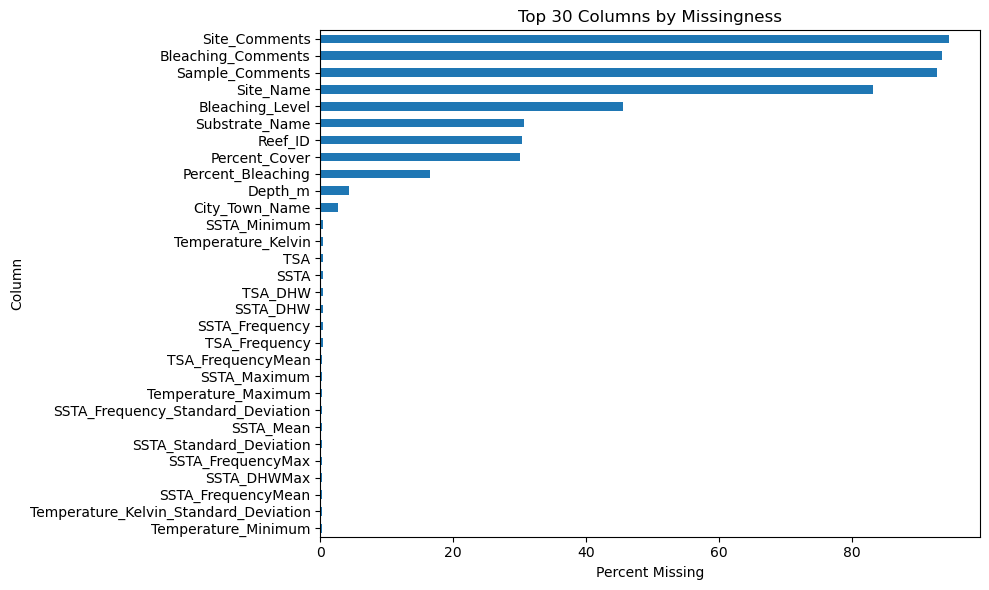

In [10]:
# Plot the missing % by column

plt.figure(figsize=(10, 6))
missing_by_col.head(30).sort_values().plot(kind="barh")
plt.xlabel("Percent Missing")
plt.ylabel("Column")
plt.title("Top 30 Columns by Missingness")
plt.tight_layout()
plt.show()

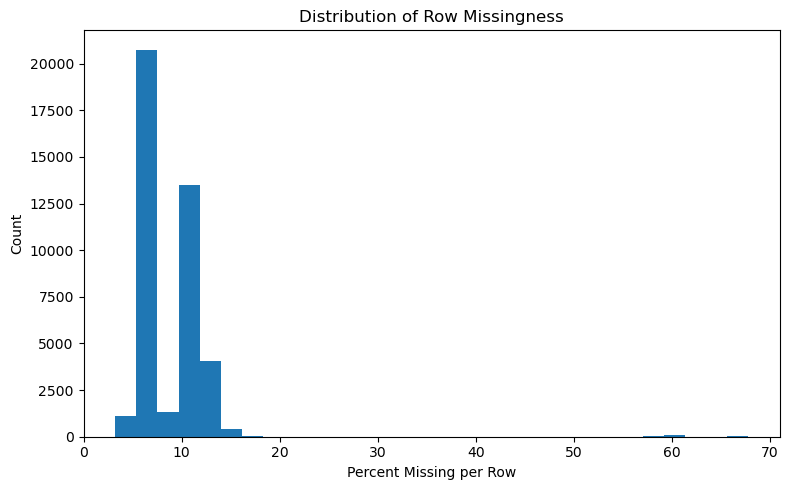

In [11]:
# Next, we look at missing values by row.

row_missing_pct = df.isna().mean(axis=1) * 100

plt.figure(figsize=(8, 5))
plt.hist(row_missing_pct, bins=30)
plt.xlabel("Percent Missing per Row")
plt.ylabel("Count")
plt.title("Distribution of Row Missingness")
plt.tight_layout()
plt.show()

In [12]:
print("Rows with 0% missing:", (row_missing_pct == 0).sum())
print("Rows with <=10% missing:", (row_missing_pct <= 10).sum())
print("Rows with <=20% missing:", (row_missing_pct <= 20).sum())

Rows with 0% missing: 0
Rows with <=10% missing: 30924
Rows with <=20% missing: 41227


In [13]:
# Next, we need to look at the distributions of observations accross the years.
print("Year summary:")
print(df[year_col].describe())

Year summary:
count    41361.000000
mean      2007.796765
std          6.073043
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2013.000000
max       2020.000000
Name: Date_Year, dtype: float64


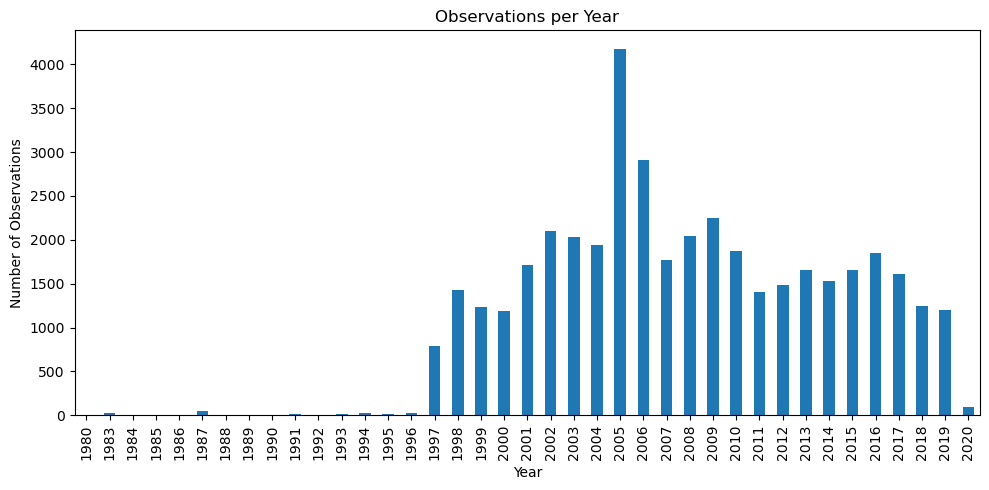

In [14]:
plt.figure(figsize=(10, 5))
df[year_col].dropna().astype(int).value_counts().sort_index().plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.title("Observations per Year")
plt.tight_layout()
plt.show()

By Plotting the observations per yer, we can see they are quite uniform. This is means we will not be over representing a certain time period in the data set.

In [15]:
# Next, let's look at the number of unique reefs in the dataset.

print("Unique reefs:", df[reef_id_col].nunique())

Unique reefs: 12702


In [16]:
obs_per_reef = df.groupby(reef_id_col).size().sort_values(ascending=False)

obs_per_reef.describe()

count    12702.000000
mean         3.256259
std          4.966805
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         90.000000
dtype: float64

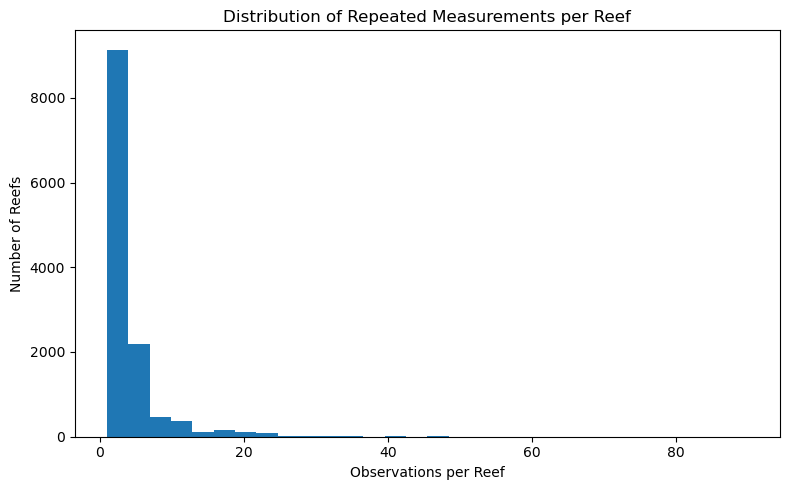

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(obs_per_reef, bins=30)
plt.xlabel("Observations per Reef")
plt.ylabel("Number of Reefs")
plt.title("Distribution of Repeated Measurements per Reef")
plt.tight_layout()
plt.show()

For PCA and clustering we are going to conduct analysis on two data sets. The first, "Analysis A", will be with all the above observations. This may bias the PCA and clustering to more heavily represent the reefs with more observations. This will probably not be representative of global reef patterns. The second analysis, "Anaslysis B", will be conducted on aggragted data so we have one row per reef. Making this separation will allow us to compare differences between findings in both A and B.

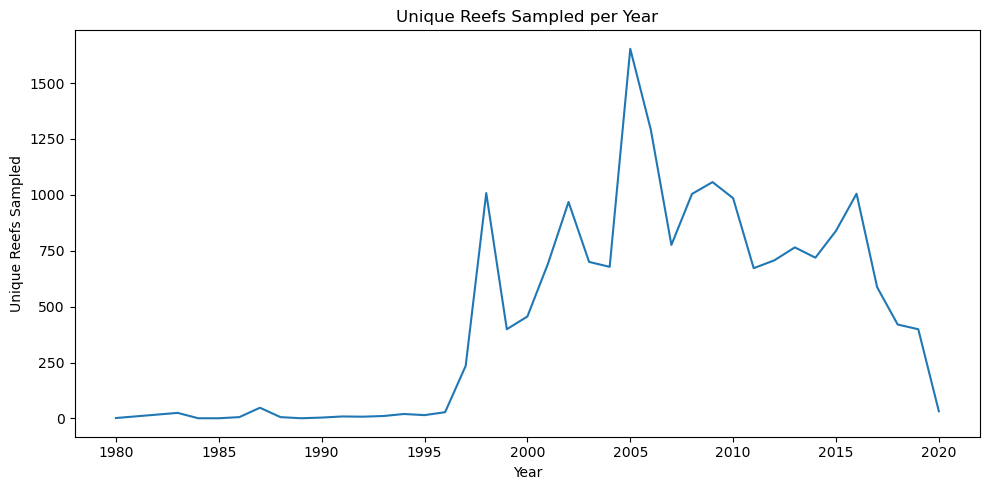

In [18]:
reef_year_counts = df.groupby(year_col)[reef_id_col].nunique()

plt.figure(figsize=(10, 5))
reef_year_counts.plot()
plt.xlabel("Year")
plt.ylabel("Unique Reefs Sampled")
plt.title("Unique Reefs Sampled per Year")
plt.tight_layout()
plt.show()

In [19]:
# Drop comluns with too many missing, redundant, or non-numeric/freetext:
cols_to_drop = [
    "Site_Comments",
    "Bleaching_Comments",
    "Sample_Comments",
    "Site_Name",
    "Bleaching_Level",
    "Substrate_Name",
    "Reef_ID",
    "Date",
    "Date_Month",
    "Date_Day"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Rename year column for convenience
df = df.rename(columns={"Date_Year": "year"})
print(df.shape)

(41361, 52)


In [20]:
print("Rows with 0% missing:", (row_missing_pct == 0).sum())
print("Rows with <=10% missing:", (row_missing_pct <= 10).sum())
print("Rows with <=20% missing:", (row_missing_pct <= 20).sum())

Rows with 0% missing: 0
Rows with <=10% missing: 30924
Rows with <=20% missing: 41227


In [21]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
print(len(numeric_cols), "numeric columns")

Numeric columns: ['Site_ID', 'Sample_ID', 'Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore', 'Turbidity', 'Cyclone_Frequency', 'year', 'Depth_m', 'Percent_Cover', 'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA', 'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean']
44 numeric columns


In [22]:
variance_series = df[numeric_cols].var(skipna=True).sort_values()
low_variance_cols = variance_series[variance_series < 1e-8].index.tolist()
print("Low variance columns:", low_variance_cols)
variance_series.head(20)

Low variance columns: ['SSTA_Mean']


SSTA_Mean                                0.000000
Turbidity                                0.003971
SSTA_Standard_Deviation                  0.050085
SSTA_Minimum                             0.394729
Temperature_Kelvin_Standard_Deviation    0.527901
TSA_Standard_Deviation                   0.530143
TSA_Frequency_Standard_Deviation         0.625264
SSTA                                     0.688083
TSA_Maximum                              0.961183
TSA_Mean                                 1.197989
TSA_DHWMean                              1.297114
SSTA_Maximum                             1.421719
SSTA_Frequency_Standard_Deviation        1.653716
TSA_DHW_Standard_Deviation               1.725040
SSTA_DHWMean                             1.733647
Temperature_Maximum                      1.741556
Temperature_Mean                         2.491750
SSTA_DHW_Standard_Deviation              2.537813
TSA                                      2.692466
TSA_FrequencyMean                        3.866385


In [23]:
#df["SSTA_Mean"].describe()
df["SSTA_Mean"].nunique()

1

In [24]:
# Drop highly corralated columns (SSTA_MAX/MIN/Mean/Median, etc)
corr = df[numeric_cols].corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated columns:", to_drop)

df = df.drop(columns=to_drop)
df = df.drop(columns = "SSTA_Mean")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Remaining numeric columns:", numeric_cols)

Highly correlated columns: ['Temperature_Kelvin_Standard_Deviation', 'SSTA_FrequencyMax', 'SSTA_DHWMean', 'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Mean', 'TSA_FrequencyMax', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMean']
Remaining numeric columns: ['Site_ID', 'Sample_ID', 'Latitude_Degrees', 'Longitude_Degrees', 'Distance_to_Shore', 'Turbidity', 'Cyclone_Frequency', 'year', 'Depth_m', 'Percent_Cover', 'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'Windspeed', 'SSTA', 'SSTA_Standard_Deviation', 'SSTA_Minimum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_FrequencyMean', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'TSA', 'TSA_Maximum', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHWMax']


Above I drop some of the highly correlated columns and the SSTA_Mean. The SSTA_Mean column contained all the same value for each row. Removing columns with correlation greater than 0.9 is to remove essentially redundant features.

In [25]:
# Recompute numeric columns from the current dataframe
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Columns that are numeric but should NOT be PCA features
id_cols = ["Site_ID", "Sample_ID", "year"]

feature_cols = [c for c in numeric_cols if c not in id_cols]

# Rebuild X fresh
X = df[feature_cols].copy()

print("X shape:", X.shape)
print("Non-numeric columns in X:")
print(X.select_dtypes(exclude=[np.number]).columns.tolist())

X shape: (41361, 31)
Non-numeric columns in X:
[]


After double checking all values are numeric we will split into the two datasets A and B.

In [26]:
# Dataset A is the entire set.

df_A = df.copy()

# Data set B is aggragated by reef:
df_B = df.groupby("Site_ID").mean(numeric_only=True)
df_B = df_B.reset_index()

# For B we also want to drop year since we are looking at a global snapshot of all reefs in B:
df_B = df_B.drop(columns=["year"], errors="ignore")

Lastly we impute missing data and standardize the data.

In [27]:
# Impute and Standardize A:
X_A = df_A[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
X_A_imputed = pd.DataFrame(
    imputer.fit_transform(X_A),
    columns=X_A.columns,
    index=X_A.index
)

scaler = StandardScaler()
X_A_scaled = pd.DataFrame(
    scaler.fit_transform(X_A_imputed),
    columns=X_A_imputed.columns,
    index=X_A_imputed.index
)

In [28]:
# For B, we need to recommpute feature columns:
numeric_cols_B = df_B.select_dtypes(include=[np.number]).columns.tolist()

id_cols_B = ["Site_ID"]
feature_cols_B = [c for c in numeric_cols_B if c not in id_cols_B]

X_B = df_B[feature_cols_B].copy()

# Next, impute and standardize B as well:
imputer_B = SimpleImputer(strategy="median")
X_B_imputed = pd.DataFrame(
    imputer_B.fit_transform(X_B),
    columns=X_B.columns,
    index=X_B.index
)

scaler_B = StandardScaler()
X_B_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_B_imputed),
    columns=X_B_imputed.columns,
    index=X_B_imputed.index
)

Let's take these sets into Analysis A and B files. 

In [ ]:
import os

os.makedirs("cleaned_data", exist_ok=True)

df_A.to_csv("cleaned_data/dataset_A.csv", index=False)
df_B.to_csv("cleaned_data/dataset_B.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data'